# EduPro Course Demand & Revenue Forecasting - Exploratory Data Analysis (EDA)
This notebook explores distributions, correlations, and relationships to find the strongest business and model drivers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create figures output dir
os.makedirs('../reports/figures', exist_ok=True)

# Load merged transaction level dataset
df_transactions = pd.read_csv('../data/processed/merged_dataset.csv')
df_courses = pd.read_csv('../data/processed/cleaned_courses.csv')
df_teachers = pd.read_csv('../data/processed/cleaned_teachers.csv')

print("Loaded transaction level dataset. Shape:", df_transactions.shape)

Loaded transaction level dataset. Shape: (10000, 20)


### 1. Revenue and Enrollment Distributions
Let's plot histograms of transaction amounts and course ratings.

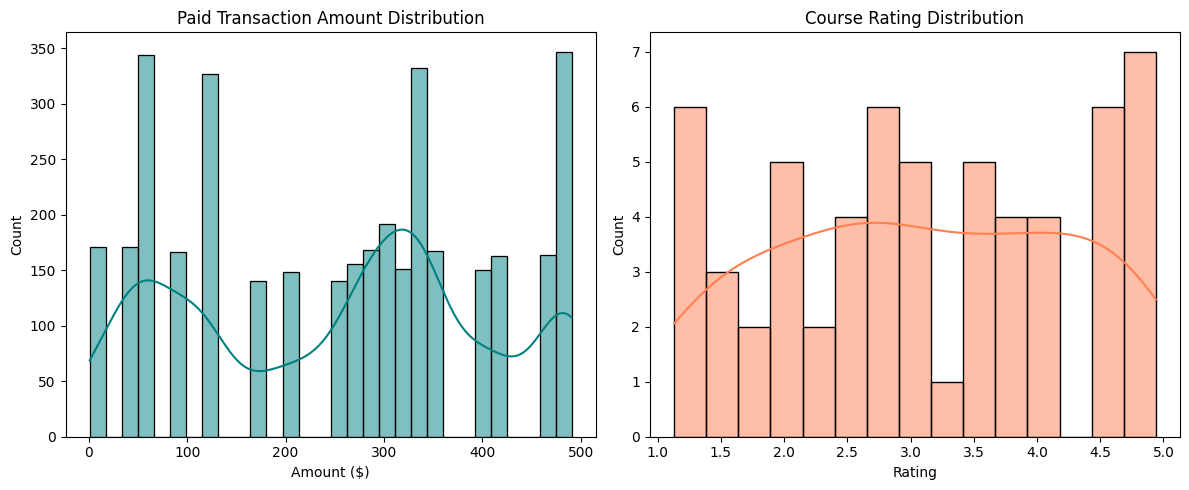

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_transactions[df_transactions['Amount'] > 0]['Amount'], bins=30, kde=True, color='teal')
plt.title('Paid Transaction Amount Distribution')
plt.xlabel('Amount ($)')

plt.subplot(1, 2, 2)
sns.histplot(df_courses['CourseRating'], bins=15, kde=True, color='coral')
plt.title('Course Rating Distribution')
plt.xlabel('Rating')

plt.tight_layout()
plt.savefig('../reports/figures/distributions.png')
plt.show()

### 2. Category-level Revenue and Demand Analysis

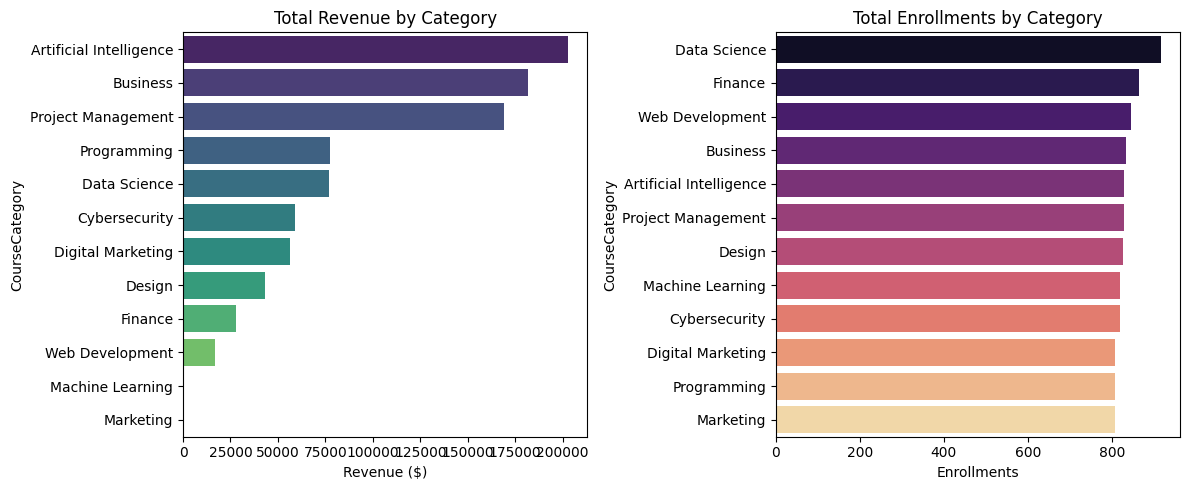

In [ ]:
# Total revenue and enrollment by category
cat_stats = df_transactions.groupby('CourseCategory').agg(
    TotalRevenue=('Amount', 'sum'),
    Enrollments=('TransactionID', 'count')
).reset_index().sort_values(by='TotalRevenue', ascending=False)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=cat_stats, x='TotalRevenue', y='CourseCategory', palette='viridis', hue='CourseCategory', legend=False)
plt.title('Total Revenue by Category')
plt.xlabel('Revenue ($)')

plt.subplot(1, 2, 2)
sns.barplot(data=cat_stats.sort_values(by='Enrollments', ascending=False), x='Enrollments', y='CourseCategory', palette='magma', hue='CourseCategory', legend=False)
plt.title('Total Enrollments by Category')
plt.xlabel('Enrollments')

plt.tight_layout()
plt.savefig('../reports/figures/category_analysis.png')
plt.show()

### 3. Teacher Revenue Contribution

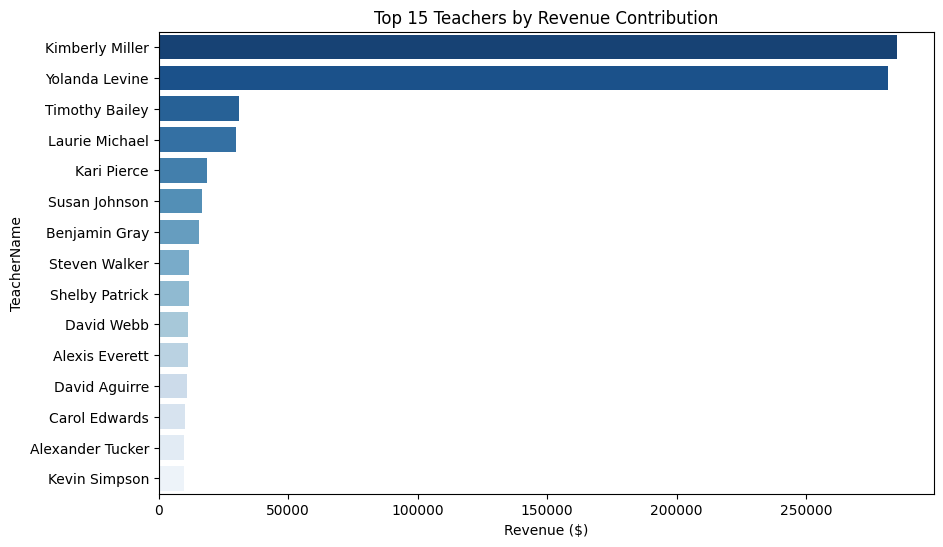

In [ ]:
teacher_revenue = df_transactions.groupby('TeacherName')['Amount'].sum().reset_index().sort_values(by='Amount', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=teacher_revenue, x='Amount', y='TeacherName', palette='Blues_r', hue='TeacherName', legend=False)
plt.title('Top 15 Teachers by Revenue Contribution')
plt.xlabel('Revenue ($)')
plt.savefig('../reports/figures/teacher_performance.png')
plt.show()

### 4. Continuous Variable Relationships
Let's check Price vs Revenue and Rating vs Enrollment.

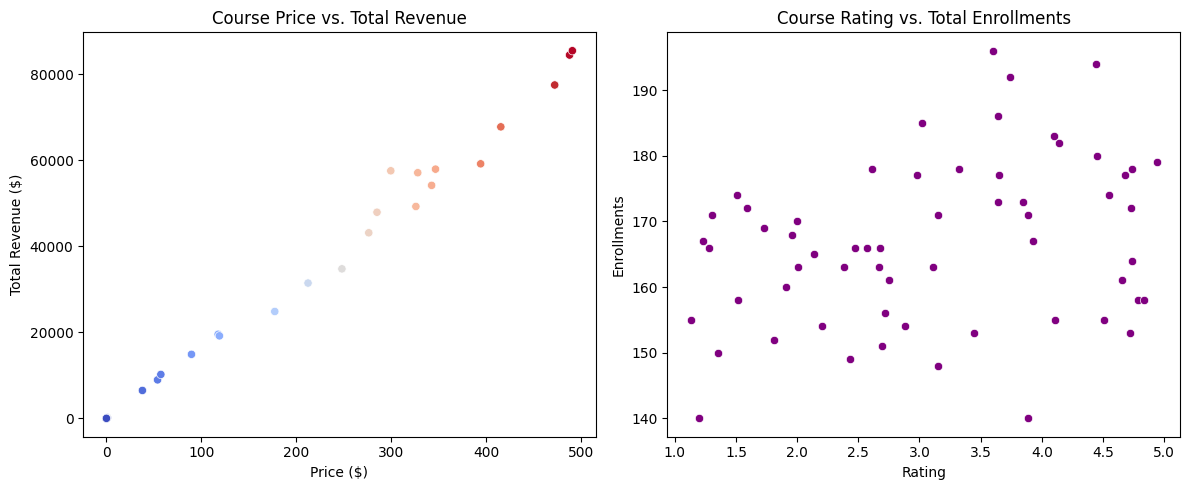

In [ ]:
course_summary = df_transactions.groupby('CourseID').agg(
    CoursePrice=('CoursePrice', 'first'),
    TotalRevenue=('Amount', 'sum'),
    CourseRating=('CourseRating', 'first'),
    TotalEnrollments=('TransactionID', 'count')
).reset_index()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=course_summary, x='CoursePrice', y='TotalRevenue', hue='CoursePrice', palette='coolwarm', legend=False)
plt.title('Course Price vs. Total Revenue')
plt.xlabel('Price ($)')
plt.ylabel('Total Revenue ($)')

plt.subplot(1, 2, 2)
sns.scatterplot(data=course_summary, x='CourseRating', y='TotalEnrollments', color='purple')
plt.title('Course Rating vs. Total Enrollments')
plt.xlabel('Rating')
plt.ylabel('Enrollments')

plt.tight_layout()
plt.savefig('../reports/figures/scatter_relations.png')
plt.show()

### 5. Correlation Analysis

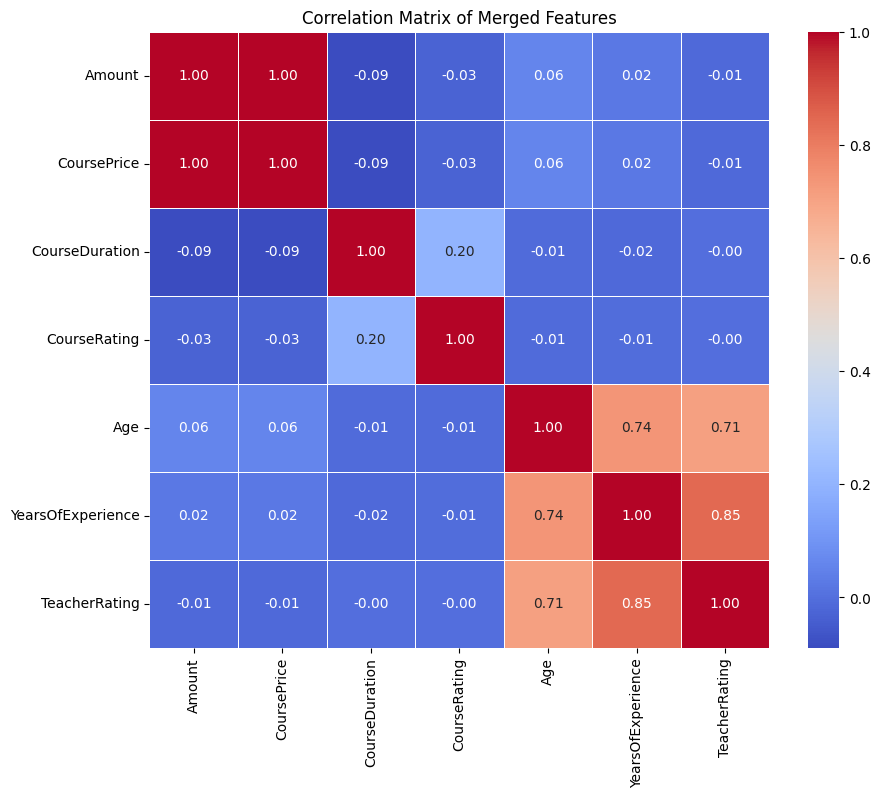

In [ ]:
# Drop non-numeric columns and calculate correlation
numeric_cols = df_transactions.select_dtypes(include=[np.number]).drop(columns=['Year'], errors='ignore')
corr = numeric_cols.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Merged Features')
plt.savefig('../reports/figures/correlation_heatmap.png')
plt.show()